In [73]:
import zipfile

zip_ref = zipfile.ZipFile('/part_2_cnn_computer_vision-20260517T133550Z-3-001.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

print("Dataset Extracted")

Dataset Extracted


In [74]:
import zipfile

zip_path = '/part_2_cnn_computer_vision-20260517T133550Z-3-001.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [75]:
import os

os.listdir('/content/dataset')

['part_2_cnn_computer_vision']

In [76]:
import os

dataset_path = "/content/dataset"

classes = os.listdir(dataset_path)

print("Classes:", classes)

Classes: ['part_2_cnn_computer_vision']


In [77]:
!pip install pillow

In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report

# **Task 2: Dataset Exploration**

## **Count Number of Classes**

In [79]:
print("Number of Classes:", len(classes))
print(classes)

Number of Classes: 1
['part_2_cnn_computer_vision']


**Count Images Per Class**

In [80]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, ":", len(os.listdir(path)))

part_2_cnn_computer_vision : 4


**Display Sample Images**

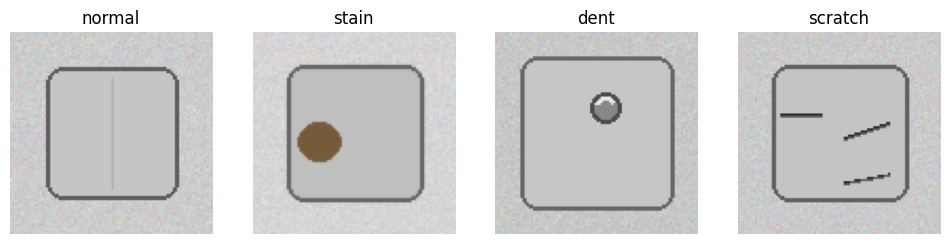

In [81]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# The original dataset_path is '/content/dataset'
# The actual images are located inside '/content/dataset/part_2_cnn_computer_vision/images'
# Adjust dataset_path for this cell to point to the directory containing class folders
image_root_path = os.path.join(dataset_path, 'part_2_cnn_computer_vision', 'images')

# Remove hidden files and get actual class names (e.g., 'healthy', 'diseased')
classes = [cls for cls in os.listdir(image_root_path) if not cls.startswith('.') and os.path.isdir(os.path.join(image_root_path, cls))]

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    class_path = os.path.join(image_root_path, cls) # This will be something like /content/dataset/part_2_cnn_computer_vision/images/healthy

    # Ignore hidden files inside folders and get image files
    image_files = [img for img in os.listdir(class_path)
                   if not img.startswith('.') and os.path.isfile(os.path.join(class_path, img))]

    # Ensure there are image files in the directory
    if not image_files:
        print(f"No image files found in {class_path}. Skipping.")
        continue

    img_name = image_files[0] # Take the first image
    img_path = os.path.join(class_path, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(1, len(classes), i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.show()

**Check Image Dimensions**

In [82]:
from PIL import Image
import os

# Ensure image_root_path is defined, as it was defined in a previous cell (-CeWPm8zeCna)
# image_root_path = os.path.join(dataset_path, 'part_2_cnn_computer_vision', 'images')

for cls in classes:
    class_dir = os.path.join(image_root_path, cls)

    # Get the first image file in the class directory, ignoring hidden files
    image_files = [f for f in os.listdir(class_dir) if not f.startswith('.') and os.path.isfile(os.path.join(class_dir, f))]

    if not image_files:
        print(f"No image files found in {class_dir}. Skipping.")
        continue

    img_name = image_files[0]
    img_path = os.path.join(class_dir, img_name)

    img = Image.open(img_path)

    print(cls, img.size)

normal (96, 96)
stain (96, 96)
dent (96, 96)
scratch (96, 96)


# **Task 3: Image Preprocessing**

**Create ImageDataGenerator**

In [83]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

**Create Training Dataset**

In [84]:
train_data = train_datagen.flow_from_directory(
    image_root_path, # Changed from dataset_path to image_root_path
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


**Create Validation Dataset**

In [85]:
val_data = train_datagen.flow_from_directory(
    image_root_path, # Changed from dataset_path to image_root_path
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


# **Task 4: CNN Model Creation**

**Build CNN Model**

In [86]:
tf.keras.backend.clear_session() # Clear any previous TensorFlow graph and variables
model = Sequential()

# First CNN Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile Model**

In [87]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Model Summary**

In [88]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

**Train CNN Model**

In [89]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.2422 - loss: 2.6593 - val_accuracy: 0.2500 - val_loss: 1.3890
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3125 - loss: 1.3738 - val_accuracy: 0.2708 - val_loss: 1.3772
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 881ms/step - accuracy: 0.3125 - loss: 1.3718 - val_accuracy: 0.5521 - val_loss: 1.2884
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 852ms/step - accuracy: 0.4740 - loss: 1.2650 - val_accuracy: 0.5938 - val_loss: 1.1271
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 953ms/step - accuracy: 0.6276 - loss: 1.0353 - val_accuracy: 0.6458 - val_loss: 0.9697
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 960ms/step - accuracy: 0.6875 - loss: 0.8930 - val_accuracy: 0.7708 - val_loss: 0.6457
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 951ms/step - accuracy: 0.6875 - loss: 0.8049 - val_accuracy: 0.7708 - val_loss: 0.7264
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 964ms/step - accuracy: 0.7526 - loss: 0.6622 - val_accuracy: 

**Plot Accuracy & Loss Graphs**

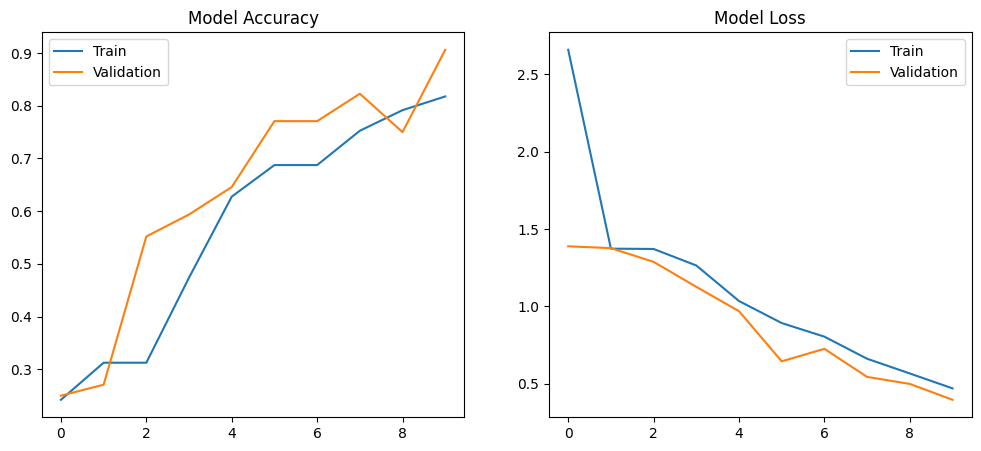

In [90]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.legend(['Train', 'Validation'])

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.legend(['Train', 'Validation'])

plt.show()

**Evaluate Model**

In [91]:
loss, accuracy = model.evaluate(val_data)

print("Loss:", loss)
print("Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 0.8438 - loss: 0.4225
Loss: 0.42252349853515625
Accuracy: 0.84375


**Confusion Matrix**

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step


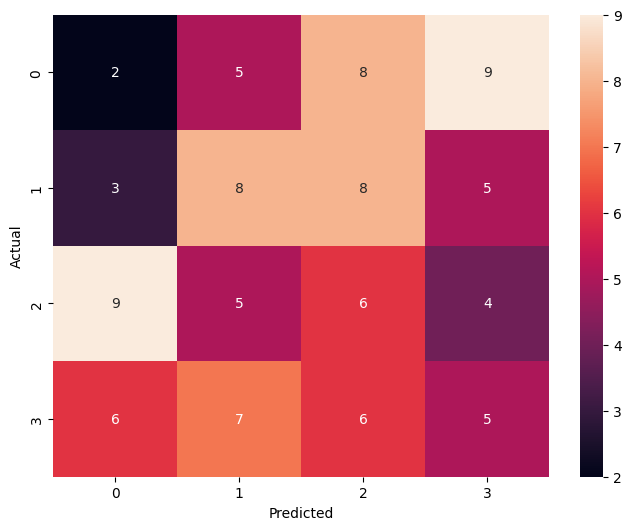

In [92]:
Y_pred = model.predict(val_data)

y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Classification Report**

In [93]:
print(classification_report(val_data.classes, y_pred))

              precision    recall  f1-score   support

           0       0.10      0.08      0.09        24
           1       0.32      0.33      0.33        24
           2       0.21      0.25      0.23        24
           3       0.22      0.21      0.21        24

    accuracy                           0.22        96
   macro avg       0.21      0.22      0.22        96
weighted avg       0.21      0.22      0.22        96



**Sample Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


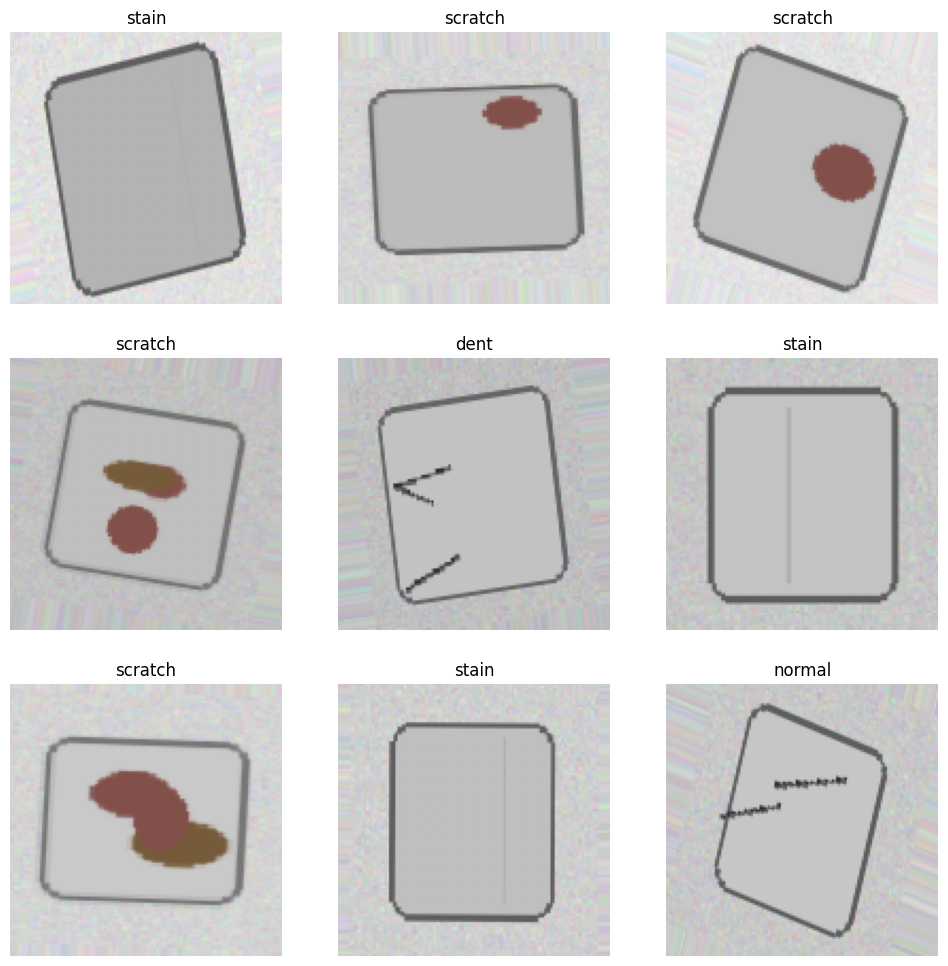

In [94]:
plt.figure(figsize=(12,12))

for i in range(9):

    img, label = next(val_data)

    prediction = model.predict(img)

    pred_class = classes[np.argmax(prediction[0])]

    plt.subplot(3,3,i+1)

    plt.imshow(img[0])

    plt.title(pred_class)

    plt.axis('off')

plt.show()

**Save Results Images**

In [95]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)

print("Folders created")

Folders created


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


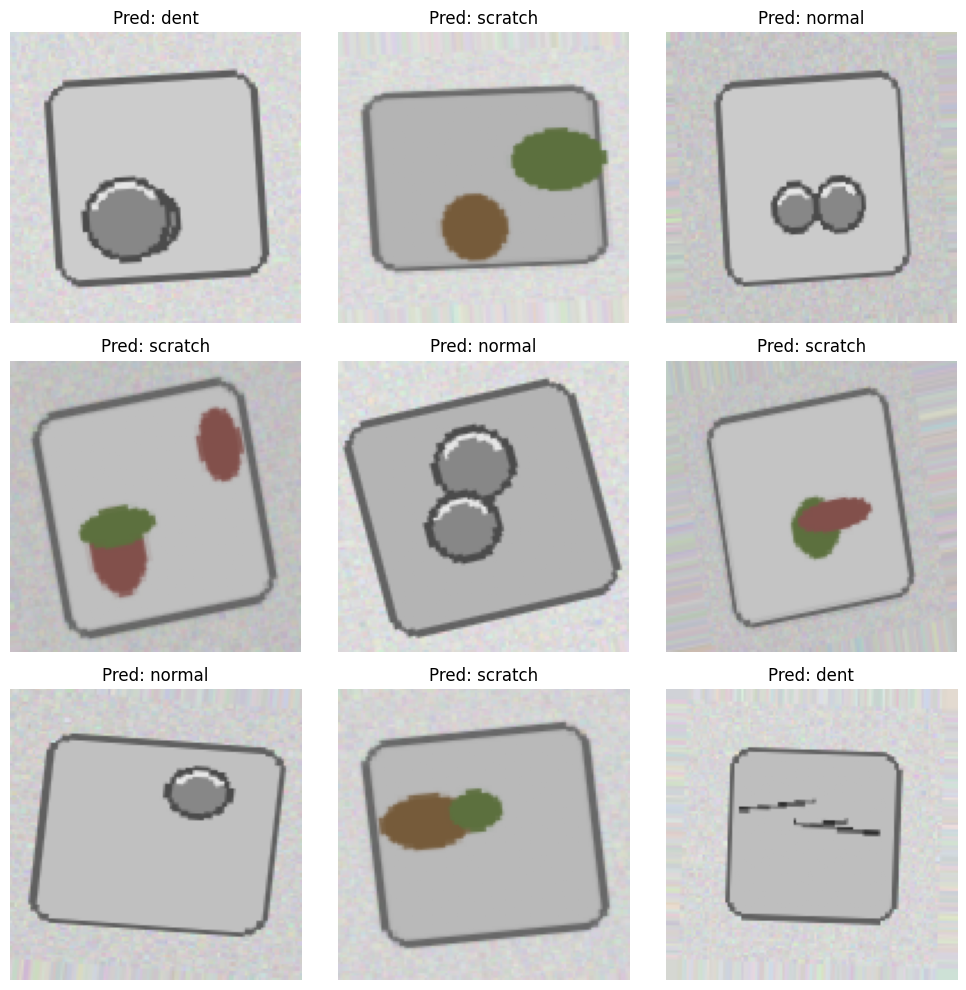

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import os

# get a batch from validation data
img_batch, label_batch = next(val_data)

fig = plt.figure(figsize=(10,10))

for i in range(9):

    img = img_batch[i]

    prediction = model.predict(np.expand_dims(img, axis=0))

    pred_class = classes[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = "sample_predictions"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

fig.savefig(os.path.join(output_dir, "prediction_outputs.png"))
plt.show()
plt.close(fig)

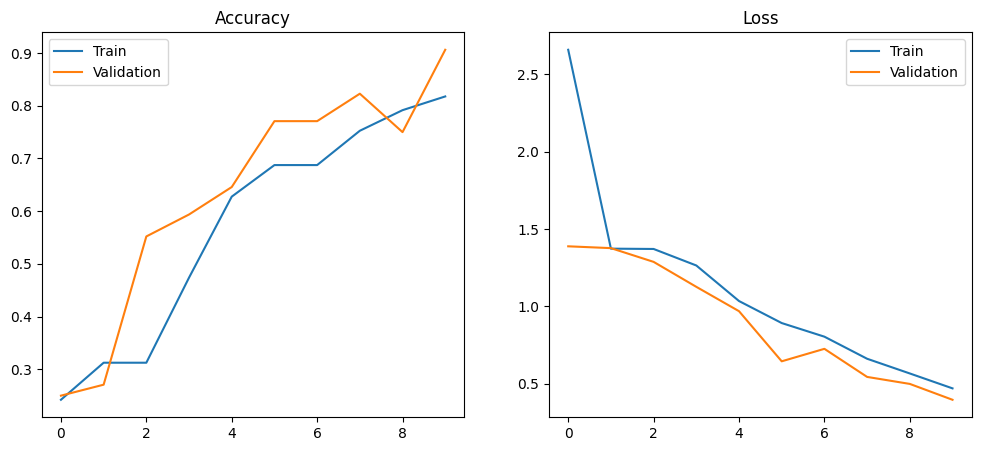

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])

plt.savefig("results/accuracy_loss_curves.png")
plt.show()

In [98]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_data.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step


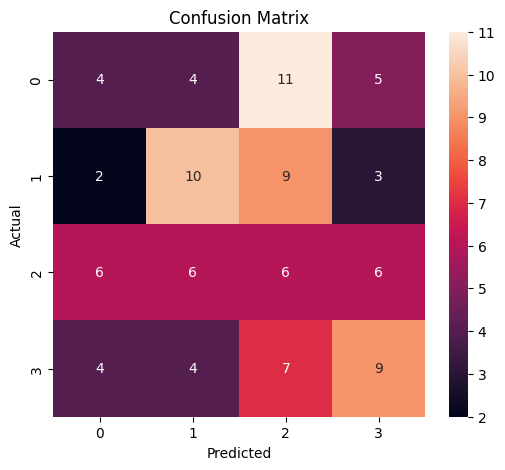

In [99]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")
plt.show()